In [6]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from math import sqrt # Import sqrt for Cramér's V calculation

# --- DATA LOADING AND PREPROCESSING ---
# NOTE: This assumes 'merged_horse_racing_data.csv' is available in the environment.
df_jt = pd.read_csv("merged_horse_racing_data.csv")

# Print the columns to verify the target variable exists
print(df_jt.head(0))

def create_target_variable(df_in):
    """Create winner column from race position (1 if position is 1, 0 otherwise)"""
    # Create the 'winner' column directly on the DataFrame
    df_in['winner'] = (df_in['race_position_clean'] == 1).astype(int)
    return df_in

# Apply the function to create the target column
df = create_target_variable(df_jt)


def run_chi_squared_test(df, cat_feature, min_threshold=30):
    """
    Performs a Chi-Squared Test and calculates Cramér's V (effect size).
    Lumps categories with frequency < min_threshold into 'Other'.
    Returns the feature name, p-value, Chi-Squared statistic, Cramér's V, and notes.
    """
    try:
        # 1. Identify high-cardinality categories to keep
        category_counts = df[cat_feature].value_counts()
        keep_categories = category_counts[category_counts >= min_threshold].index

        # 2. Create a modified feature for the test
        df_temp = df.copy()
        # Lump low-frequency categories into 'Other'
        df_temp['temp_cat_for_test'] = np.where(
            df_temp[cat_feature].isin(keep_categories),
            df_temp[cat_feature],
            'Other'
        )

        # 3. Create the Contingency Table (crosstab)
        contingency_table = pd.crosstab(df_temp['temp_cat_for_test'], df_temp['winner'])

        # Pre-check for chi2_contingency requirements (must have dimensions > 1)
        if contingency_table.shape[0] <= 1 or contingency_table.shape[1] <= 1:
            return cat_feature, 1.0, 0.0, 0.0, "Skipped (Insufficient variance after lumping)"

        # 4. Run the Chi-Squared Test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        # 5. Calculate Cramér's V (Effect Size)
        N = contingency_table.values.sum() # Total sample size in the table
        r, k = contingency_table.shape      # r = rows (categories), k = columns (winner: 0/1)
        
        # Denominator: min(r-1, k-1)
        phi2 = chi2 / N
        min_dim = min(r - 1, k - 1)
        
        # Note: If min_dim is 0 (which should be caught by the pre-check), V would be undefined.
        if min_dim == 0:
             cramers_v = 0.0
        else:
             cramers_v = sqrt(phi2 / min_dim)
        
        return cat_feature, p_value, chi2, cramers_v, f"Categories Kept: {len(keep_categories) + 1} (incl. 'Other')"

    except KeyError:
        return cat_feature, 1.0, 0.0, 0.0, "Column Not Found"
    except Exception as e:
        # Catch other potential errors, like math errors in chi2_contingency
        return cat_feature, 1.0, 0.0, 0.0, f"Error during Chi2: {type(e).__name__}"


# --- MAIN EXECUTION BLOCK ---

categorical_columns = [
    "track_name_clean",
    "going_clean",
    "distance_clean",
    "horse_name_clean",
    "jockey_clean",
    "trainer_clean",
    "claims_clean",
    "first_place_found_clean",
    "source_file" # File name is often a categorical label
]

# List to store the results of the Chi-Squared tests
chi_squared_results = []

print("--- Starting Chi-Squared Feature Ranking Analysis ---")
print(f"Target Variable: 'winner' (1=Win, 0=Loss/Place)")
print(f"Minimum Category Threshold: {30} (Lumped into 'Other')\n")


# Iterate over the array of categorical columns and run the test
for col in categorical_columns:
    print(f"Running test for {col}...")
    # Call the modified function and unpack the results (now 4 returned values + notes)
    feature, p_value, chi2_stat, cramers_v, notes = run_chi_squared_test(df, col, min_threshold=30)
    
    # Store the results
    chi_squared_results.append({
        'Feature': feature,
        'Cramers_V': cramers_v, # Added Cramér's V
        'P_Value': p_value,
        'Chi2_Stat': chi2_stat,
        'Notes': notes
    })


# Convert results to a DataFrame for easy sorting and printing
results_df = pd.DataFrame(chi_squared_results)

# Sort the results by Cramér's V descending (strongest association first)
ranked_results = results_df.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("       STATISTICAL FEATURE RANKING (Chi-Squared & Cramér's V)")
print("="*70)
print("Ranking by Cramér's V (Effect Size):")
print("V $\\to$ 1.0 indicates a stronger association with the winner variable.")

# FIX: Changed floatfmt from a dictionary to an ordered tuple to resolve the ValueError.
# The order matches the float columns: Cramers_V (.4f), P_Value (.10f), Chi2_Stat (.2f).
print("\n" + ranked_results.to_markdown(index=False, floatfmt=(".4f", ".10f", ".2f"))) 
print("\n--- Analysis Complete ---")
print("`Cramér's V` is the effect size (0 to 1.0) and is the categorical equivalent of a correlation coefficient.")


Empty DataFrame
Columns: [track_name, race_date, race_time, going, distance, horse_name, jockey, claims, trainer, race_position, lost_by_length, age, weight, rating, first_place_found, batch_number, url_index_in_batch, source_file, race_position_clean, lost_by_length_clean, rating_clean, weight_clean, track_name_clean, race_date_clean, race_time_clean, going_clean, distance_clean, horse_name_clean, jockey_clean, trainer_clean, claims_clean, age_clean, first_place_found_clean]
Index: []

[0 rows x 33 columns]
--- Starting Chi-Squared Feature Ranking Analysis ---
Target Variable: 'winner' (1=Win, 0=Loss/Place)
Minimum Category Threshold: 30 (Lumped into 'Other')

Running test for track_name_clean...
Running test for going_clean...
Running test for distance_clean...
Running test for horse_name_clean...
Running test for jockey_clean...
Running test for trainer_clean...
Running test for claims_clean...
Running test for first_place_found_clean...
Running test for source_file...

       STATI

In [21]:
import pandas as pd
import numpy as np
import re
from datetime import datetime

# ======================================================================
#           GOING FEATURES PREPROCESSING PIPELINE
# ======================================================================

class GoingFeaturesPreprocessor:
    """
    Temporal going features pipeline for horse racing prediction.
    Creates performance, binary, and interaction features WITHOUT data leakage.
    """
    
    GOING_SCALE = [
        "Firm", "Good to Firm", "Good", "Good to Yielding",
        "Yielding", "Yielding to Soft", "Soft", "Soft to Heavy",
        "Heavy", "Standard"
    ]
    
    # Top 10 features to keep (r >= 0.028)
    FEATURES_TO_KEEP = [
        'performance_on_Good',
        'active_perf_on_Good',
        'has_exp_on_Good',
        'performance_on_Good to Yielding',
        'performance_on_Soft',
        'has_exp_on_Good to Yielding',
        'has_exp_on_Soft',
        'performance_on_Yielding',
        'active_perf_on_Standard',
        'has_exp_on_Yielding'
    ]
    
    def __init__(self, verbose=True):
        self.verbose = verbose
    
    def _log(self, message):
        if self.verbose:
            print(message)
    
    def _extract_clean_going(self, raw_going):
        """Extract standardized going from raw text"""
        if not isinstance(raw_going, str):
            return None
        
        raw = raw_going.lower().replace('-', ' ').strip()
        
        # Check multi-word matches first (longest first)
        for going in sorted(self.GOING_SCALE, key=lambda g: -len(g)):
            pattern = r'\b' + re.escape(going.lower()) + r'\b'
            if re.search(pattern, raw):
                return going
        
        # Check individual words
        tokens = re.findall(r'\b\w+\b', raw)
        for token in tokens:
            for going in self.GOING_SCALE:
                if token == going.lower():
                    return going
        return None
    
    def _extract_race_date(self, track_name):
        """Extract race date from track_name column"""
        if not isinstance(track_name, str):
            return None
        
        new = track_name.split('|', 1)[-1]
        cleaned_string = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', new)
        
        try:
            date_object = datetime.strptime(cleaned_string, " %d %B %Y %H:%M")
            return date_object.strftime("%d/%m/%Y")
        except:
            return None
    
    def fit_transform(self, df):
        """
        Complete preprocessing pipeline.
        
        Args:
            df: Raw dataframe with columns: track_name, going, race_position_clean, horse_name_clean
        
        Returns:
            Processed dataframe with top 10 going features
        """
        self._log("="*70)
        self._log("GOING FEATURES PREPROCESSING PIPELINE")
        self._log("="*70)
        
        df = df.copy()
        
        # Step 1: Create label
        self._log("\n[1/7] Creating target label...")
        df['label'] = (df['race_position_clean'] == 1).astype(int)
        self._log(f"      Winners: {df['label'].sum():,} / {len(df):,} races")
        
        # Step 2: Extract and parse race date
        self._log("\n[2/7] Extracting race dates...")
        df['race_date'] = df['track_name'].apply(self._extract_race_date)
        df['race_date'] = pd.to_datetime(df['race_date'], format='%d/%m/%Y', errors='coerce')
        valid_dates = df['race_date'].notna().sum()
        self._log(f"      Valid dates: {valid_dates:,} / {len(df):,} ({valid_dates/len(df)*100:.1f}%)")
        
        # Step 3: Clean going column
        self._log("\n[3/7] Cleaning going conditions...")
        df['going_raw'] = df['going'].str.split('(').str[0].str.strip()
        df['going'] = df['going_raw'].apply(self._extract_clean_going)
        unique_goings = df['going'].nunique()
        self._log(f"      Unique going types: {unique_goings}")
        
        # Step 4: Sort for temporal calculation
        self._log("\n[4/7] Sorting by horse and date...")
        df = df.sort_values(['horse_name_clean', 'race_date']).reset_index(drop=True)
        
        # Step 5: Create temporal performance features
        self._log("\n[5/7] Creating temporal performance features...")
        going_types = df['going'].dropna().unique()
        
        for going_type in going_types:
            going_mask = df['going'] == going_type
            
            # Temporary columns for cumulative calculation
            df['_temp_win'] = (going_mask & (df['label'] == 1)).astype(int)
            df['_temp_race'] = going_mask.astype(int)
            
            # Cumulative sums per horse
            grouped = df.groupby('horse_name_clean')
            cumsum_wins = grouped['_temp_win'].cumsum()
            cumsum_races = grouped['_temp_race'].cumsum()
            
            # Shift to get BEFORE current race
            wins_before = cumsum_wins - df['_temp_win']
            races_before = cumsum_races - df['_temp_race']
            
            # Calculate win rate
            perf_col = f'performance_on_{going_type}'
            df[perf_col] = np.where(races_before > 0, wins_before / races_before, 0.0)
            
            df.drop(['_temp_win', '_temp_race'], axis=1, inplace=True)
        
        self._log(f"      Created {len(going_types)} performance features")
        
        # Step 6: Create binary and interaction features
        self._log("\n[6/7] Creating binary and interaction features...")
        
        perf_features = [col for col in df.columns if col.startswith('performance_on_')]
        
        for perf_feat in perf_features:
            going_type = perf_feat.replace('performance_on_', '')
            
            # Binary: has experience
            binary_feat = f'has_exp_on_{going_type}'
            df[binary_feat] = (df[perf_feat] > 0).astype(int)
            
            # Interaction: performance when racing on this going
            interaction_feat = f'active_perf_on_{going_type}'
            is_current_going = (df['going'] == going_type).astype(int)
            df[interaction_feat] = df[perf_feat] * is_current_going
        
        total_created = len(perf_features) * 3  # perf + binary + interaction
        self._log(f"      Created {total_created} total going features")
        
        # Step 7: Filter to top 10 features only
        self._log("\n[7/7] Filtering to top 10 features...")
        
        # Essential columns
        essential_cols = ['horse_name_clean', 'race_date', 'label', 'going']
        essential_cols = [c for c in essential_cols if c in df.columns]
        
        # Keep only top features that exist
        keep_features = [f for f in self.FEATURES_TO_KEEP if f in df.columns]
        
        final_cols = essential_cols + keep_features
        df_final = df[final_cols].copy()
        
        self._log(f"      Kept {len(keep_features)} / {total_created} features")
        self._log(f"      Final columns: {len(df_final.columns)} total")
        
        # Summary statistics
        self._log("\n" + "="*70)
        self._log("PIPELINE SUMMARY")
        self._log("="*70)
        self._log(f"Input rows:       {len(df):,}")
        self._log(f"Output rows:      {len(df_final):,}")
        self._log(f"Output columns:   {len(df_final.columns)}")
        self._log(f"Essential cols:   {len(essential_cols)}")
        self._log(f"Feature cols:     {len(keep_features)}")
        self._log(f"Memory usage:     {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        return df_final
    
    def get_feature_info(self):
        """Return information about the features being created"""
        info = {
            'total_features': len(self.FEATURES_TO_KEEP),
            'feature_types': {
                'performance': sum(1 for f in self.FEATURES_TO_KEEP if f.startswith('performance_')),
                'binary': sum(1 for f in self.FEATURES_TO_KEEP if f.startswith('has_exp_')),
                'interaction': sum(1 for f in self.FEATURES_TO_KEEP if f.startswith('active_'))
            },
            'features': self.FEATURES_TO_KEEP
        }
        return info


# ======================================================================
#                    JUPYTER CELL USAGE
# ======================================================================

# Load data
df = pd.read_csv('merged_horse_racing_data.csv')

# Initialize and run pipeline
preprocessor = GoingFeaturesPreprocessor(verbose=True)
df_processed = preprocessor.fit_transform(df)

# Display feature info
print("\n" + "="*70)
print("FEATURE BREAKDOWN")
print("="*70)
feature_info = preprocessor.get_feature_info()
print(f"Total features: {feature_info['total_features']}")
print(f"\nBy type:")
for feat_type, count in feature_info['feature_types'].items():
    print(f"  - {feat_type.capitalize()}: {count}")

print(f"\nFeature list:")
for i, feat in enumerate(feature_info['features'], 1):
    feat_type = feat.split('_')[0]
    print(f"  {i:2d}. {feat:40s} [{feat_type}]")

# Preview processed data
print("\n" + "="*70)
print("PROCESSED DATA PREVIEW")
print("="*70)
print(df_processed.head(10))

# Check for missing values
print("\n" + "="*70)
print("MISSING VALUES CHECK")
print("="*70)
missing = df_processed.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("✓ No missing values!")

# Save processed data (optional)
# df_processed.to_csv('processed_going_features.csv', index=False)
# print("\n✓ Saved to 'processed_going_features.csv'")

GOING FEATURES PREPROCESSING PIPELINE

[1/7] Creating target label...
      Winners: 8,780 / 106,250 races

[2/7] Extracting race dates...
      Valid dates: 80,094 / 106,250 (75.4%)

[3/7] Cleaning going conditions...
      Unique going types: 9

[4/7] Sorting by horse and date...

[5/7] Creating temporal performance features...
      Created 9 performance features

[6/7] Creating binary and interaction features...
      Created 27 total going features

[7/7] Filtering to top 10 features...
      Kept 10 / 27 features
      Final columns: 14 total

PIPELINE SUMMARY
Input rows:       106,250
Output rows:      106,250
Output columns:   14
Essential cols:   4
Feature cols:     10
Memory usage:     22.16 MB

FEATURE BREAKDOWN
Total features: 10

By type:
  - Performance: 4
  - Binary: 4
  - Interaction: 2

Feature list:
   1. performance_on_Good                      [performance]
   2. active_perf_on_Good                      [active]
   3. has_exp_on_Good                          [has]
 

In [ ]:
import pandas as pd
import numpy as np
import re
from datetime import datetime

class JTTemporalFeatureEngineer:
    """
    A class to create temporal (look-ahead free) features for Jockey/Trainer combinations.

    It calculates the cumulative wins and runs for a specific J/T pair, ensuring that
    for any given race, only results from races that occurred *before* that date
    are included.
    """

    def __init__(self, df: pd.DataFrame):
        """Initializes the engineer with the DataFrame."""
        self.df = df
        
    def _extract_race_date(self, track_name: str) -> str:
        """
        Extracts the race date from the track_name column, using the user's specific logic.

        Args:
            track_name: The string containing the track, date, and time (e.g., 'Ascot | 17th October 2025 15:30').
            
        Returns:
            A date string in 'DD/MM/YYYY' format, or None if parsing fails.
        """
        if not isinstance(track_name, str):
            return None
        
        # Split off the track name part
        new = track_name.split('|', 1)[-1]
        
        # Remove ordinal suffixes (1st, 2nd, 3rd, 4th -> 1, 2, 3, 4)
        cleaned_string = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', new)
        
        try:
            # Attempt to parse the cleaned string into a datetime object
            # Note: This pattern expects a leading space: " 17 October 2025 15:30"
            date_object = datetime.strptime(cleaned_string.strip(), "%d %B %Y %H:%M")
            return date_object.strftime("%d/%m/%Y")
        except Exception:
            # Catch all exceptions (ValueError, etc.) if the format doesn't match
            return None

    def create_jt_temporal_features(df) -> pd.DataFrame:
        """
        Creates the temporal J/T runs and wins features.

        Args:
            jockey_col: Name of the column containing jockey ID/name.
            trainer_col: Name of the column containing trainer ID/name.
            winner_col: Name of the target column (1 for win, 0 for loss).
            track_name_col: Name of the column used to extract the race date.

        Returns:
            The DataFrame with the new temporal features appended.
        """
        jockey_col = "jockey_clean"
        trainer_col = "trainer_clean"
        winner_col = "winner"
        track_name_col = "track_name"

        # Save the initial length to correctly report dropped rows
        initial_length = len(df)
        df = df.copy()

        # 1. Create the unique J/T combination feature (j_t)
        df['j_t'] = df[jockey_col].astype(str) + '__' + df[trainer_col].astype(str)
        print("✓ 'j_t' feature created.")

        # 2. Extract and convert the date for temporal sorting
        df['race_date_str'] = df[track_name_col].apply(_extract_race_date)
        
        # Convert to datetime object for accurate sorting, coercing errors to NaT
        df['race_datetime'] = pd.to_datetime(df['race_date_str'], format='%d/%m/%Y', errors='coerce')
        
        # Drop rows where date parsing failed
        df.dropna(subset=['race_datetime'], inplace=True)
        print(f"✓ Race dates parsed. Removed {initial_length - len(df)} rows with invalid dates.")

        # 3. Sort the DataFrame by the race date (critical for temporal logic)
        # Note: If two races happen on the same date, the internal row order is used,
        # which is usually fine for cumulative calculations.
        df.sort_values(by='race_datetime', inplace=True)
        print("✓ DataFrame sorted temporally.")

        # 4. Temporal Feature Calculation (Groupby + Cumulative + Shift)

        # j_t_runs: The number of times this J/T pair ran BEFORE the current race.
        # cumcount() starts at 0 for the first item in a group.
        df['j_t_runs'] = df.groupby('j_t').cumcount()

        # j_t_wins: The number of wins this J/T pair had BEFORE the current race.
        # shift(1) ensures the current race result is excluded (look-ahead free).
        df['j_t_wins'] = df.groupby('j_t')[winner_col].cumsum().shift(1).fillna(0).astype(int)

        print("✓ Temporal features 'j_t_runs' and 'j_t_wins' created.")
        
        # 5. Calculate j_t_win_rate (avoid division by zero)
        df['j_t_win_rate'] = np.where(
            df['j_t_runs'] > 0,
            df['j_t_wins'] / df['j_t_runs'],
            0.0
        )
        print("✓ 'j_t_win_rate' calculated.")

        # 6. Clean up temporary columns - ADDED errors='ignore' for safety
        df.drop(columns=['race_date_str', 'race_datetime'], inplace=True, errors='ignore')
        print("✓ Temporary columns cleaned up.")
        
        return df

# --- Demonstration ---

# 1. Create Mock Data

df_raw = pd.DataFrame(df)

print("--- Input Data ---")
print(df_raw[['track_name', 'jockey', 'trainer', 'winner']])
print("-" * 30)

# 2. Run the Feature Engineering
engineer = JTTemporalFeatureEngineer(df_raw)
df_processed = engineer.create_jt_temporal_features(
    jockey_col='jockey', 
    trainer_col='trainer', 
    winner_col='winner', 
    track_name_col='track_name'
)

# 3. Display Results (Sorted by Date for Verification)
print("\n--- Processed Data (Sorted by Race Date) ---")
print("Check Row 3 (J1__T1's 3rd race):")
print("  - j_t_runs should be 2 (races on 15th July)")
print("  - j_t_wins should be 1 (win on 15th July)")
print("-" * 30)
# Note: I removed 'race_date_str' from the final print statement here because it is deleted 
# in the final step, but you can re-add it if you comment out the final drop.
print(df_processed[[
    'j_t',
    'jockey',
    'trainer',
    'winner',
    'j_t_runs',
    'j_t_wins',
    'j_t_win_rate'
]])

print(df_processed['j_t_win_rate'].describe())



--- Input Data ---
                                            track_name             jockey  \
0         Curragh Racing Results | 1st June 2022 17:10     D. W. O'Connor   
1         Curragh Racing Results | 1st June 2022 17:10         G. M. Ryan   
2         Curragh Racing Results | 1st June 2022 17:10  William James Lee   
3         Curragh Racing Results | 1st June 2022 17:10     A. J. Slattery   
4         Curragh Racing Results | 1st June 2022 17:10       R. C. Colgan   
...                                                ...                ...   
106245  Limerick Racing Results | 11th June 2025 20:20            S Foley   
106246  Limerick Racing Results | 11th June 2025 20:20       A J Slattery   
106247  Limerick Racing Results | 11th June 2025 20:20        D McMonagle   
106248  Limerick Racing Results | 11th June 2025 20:20        M W Hassett   
106249  Limerick Racing Results | 11th June 2025 20:20       Jessica Maye   

                       trainer  winner  
0        Damian

In [ ]:
categorical_columns = df_processed[[
    'j_t',
    'jockey',
    'trainer',
    'winner',
    'j_t_runs',
    'j_t_wins',
    'j_t_win_rate'
]]


for col in categorical_columns:
    print(f"Running test for {col}...")
    # Call the modified function and unpack the results (now 4 returned values + notes)
    feature, p_value, chi2_stat, cramers_v, notes = run_chi_squared_test(df_processed, col, min_threshold=30)
    
    # Store the results
    chi_squared_results.append({
        'Feature': feature,
        'Cramers_V': cramers_v, # Added Cramér's V
        'P_Value': p_value,
        'Chi2_Stat': chi2_stat,
        'Notes': notes
    })


# Convert results to a DataFrame for easy sorting and printing
results_df = pd.DataFrame(chi_squared_results)

# Sort the results by Cramér's V descending (strongest association first)
ranked_results = results_df.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("       STATISTICAL FEATURE RANKING (Chi-Squared & Cramér's V)")
print("="*70)
print("Ranking by Cramér's V (Effect Size):")
print("V $\\to$ 1.0 indicates a stronger association with the winner variable.")

# FIX: Changed floatfmt from a dictionary to an ordered tuple to resolve the ValueError.
# The order matches the float columns: Cramers_V (.4f), P_Value (.10f), Chi2_Stat (.2f).
print("\n" + ranked_results.to_markdown(index=False, floatfmt=(".4f", ".10f", ".2f"))) 
print("\n--- Analysis Complete ---")
print("`Cramér's V` is the effect size (0 to 1.0) and is the categorical equivalent of a correlation coefficient.")




Running test for j_t...
Running test for jockey...
Running test for trainer...
Running test for winner...
Running test for j_t_runs...
Running test for j_t_wins...
Running test for j_t_win_rate...

       STATISTICAL FEATURE RANKING (Chi-Squared & Cramér's V)
Ranking by Cramér's V (Effect Size):
V $\to$ 1.0 indicates a stronger association with the winner variable.

| Feature                 |    Cramers_V |   P_Value |    Chi2_Stat | Notes                                         |
|:------------------------|-------------:|----------:|-------------:|:----------------------------------------------|
| race_position_clean     | 1.0000000000 |      0.00 | 106250       | Categories Kept: 26 (incl. 'Other')           |
| race_position           | 1.0000000000 |      0.00 | 106250       | Categories Kept: 33 (incl. 'Other')           |
| winner                  | 0.9999379226 |      0.00 | 106237       | Categories Kept: 3 (incl. 'Other')            |
| winner                  | 0.9999379226 

favs:

*  j_t_win_rate            | 0.0593449393 |      0.00 |    282.077   | Categories Kept: 153 (incl. 'Other')          |
*  j_t_runs                | 0.1063685054 |      0.00 |    906.204   | Categories Kept: 185 (incl. 'Other')          |
*  j_t_wins                | 0.0324491797 |      0.01 |     84.3349  | Categories Kept: 58 (incl. 'Other')           |


In [ ]:
## Load the base data once at the top
df = pd.read_csv('merged_horse_racing_data.csv')
df['winner'] = (df['race_position_clean'] == 1).astype(int)

# Make sure df is sorted first!
df = df.sort_values(['horse_name_clean', 'track_name']).reset_index(drop=True)

# Initialize empty results list
chi_squared_results = []

# Feature 1: avg_position
print("Creating avg_position...")
df['avg_position'] = (df.groupby('horse_name_clean')['race_position_clean']
                        .shift(1)
                        .groupby(df['horse_name_clean'])
                        .expanding()
                        .mean()
                        .reset_index(level=0, drop=True))

feature, p_value, chi2_stat, cramers_v, notes = run_chi_squared_test(df, 'avg_position', min_threshold=30)
chi_squared_results.append({
    'Feature': feature,
    'Cramers_V': cramers_v,
    'P_Value': p_value,
    'Chi2_Stat': chi2_stat,
    'Notes': notes
})

# Feature 2: avg_LLB
print("Creating avg_LLB...")
df['avg_LLB'] = (df.groupby('horse_name_clean')['lost_by_length_clean']
                   .shift(1)
                   .groupby(df['horse_name_clean'])
                   .expanding()
                   .mean()
                   .reset_index(level=0, drop=True))

feature, p_value, chi2_stat, cramers_v, notes = run_chi_squared_test(df, 'avg_LLB', min_threshold=30)
chi_squared_results.append({
    'Feature': feature,
    'Cramers_V': cramers_v,
    'P_Value': p_value,
    'Chi2_Stat': chi2_stat,
    'Notes': notes
})

# Convert to DataFrame and display
results_df = pd.DataFrame(chi_squared_results)
ranked_results = results_df.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("TEMPORAL FEATURES ANALYSIS")
print("="*70)
print(ranked_results.to_markdown(index=False, floatfmt=(".10f", ".10f", ".2f")))
print(f"\nTotal features created: {len(chi_squared_results)}")



Creating avg_position...
Creating avg_LLB...

TEMPORAL FEATURES ANALYSIS
| Feature      |    Cramers_V |   P_Value |   Chi2_Stat | Notes                                |
|:-------------|-------------:|----------:|------------:|:-------------------------------------|
| avg_position | 0.1305755481 |      0.00 |    1811.56  | Categories Kept: 402 (incl. 'Other') |
| avg_LLB      | 0.0743286871 |      0.00 |     587.005 | Categories Kept: 392 (incl. 'Other') |

Total features created: 2


Parsing race dates...
Removed 0 rows with invalid dates
Remaining rows: 53478

Calculating rest periods...
Rows with rest period data: 44039

Aggregating population patterns...
Stable rest period bins: 170

Top 10 rest periods by win rate:
     days_rest  win_rate  n_races
176      176.0  0.161290       31
143      143.0  0.156250       32
132      132.0  0.151515       33
88        88.0  0.145455       55
141      141.0  0.142857       42
122      122.0  0.138889       36
161      161.0  0.134615       52
57        57.0  0.129944      177
156      156.0  0.129032       31
63        63.0  0.128492      179

Fitting performance curve...

🏆 RESULTS (Weighted):
   Optimal rest period: 32.2 days
   Peak win rate: 9.4%
   Baseline win rate: -0.1%
   Optimal window (1 std dev): 0.0 to 69.3 days


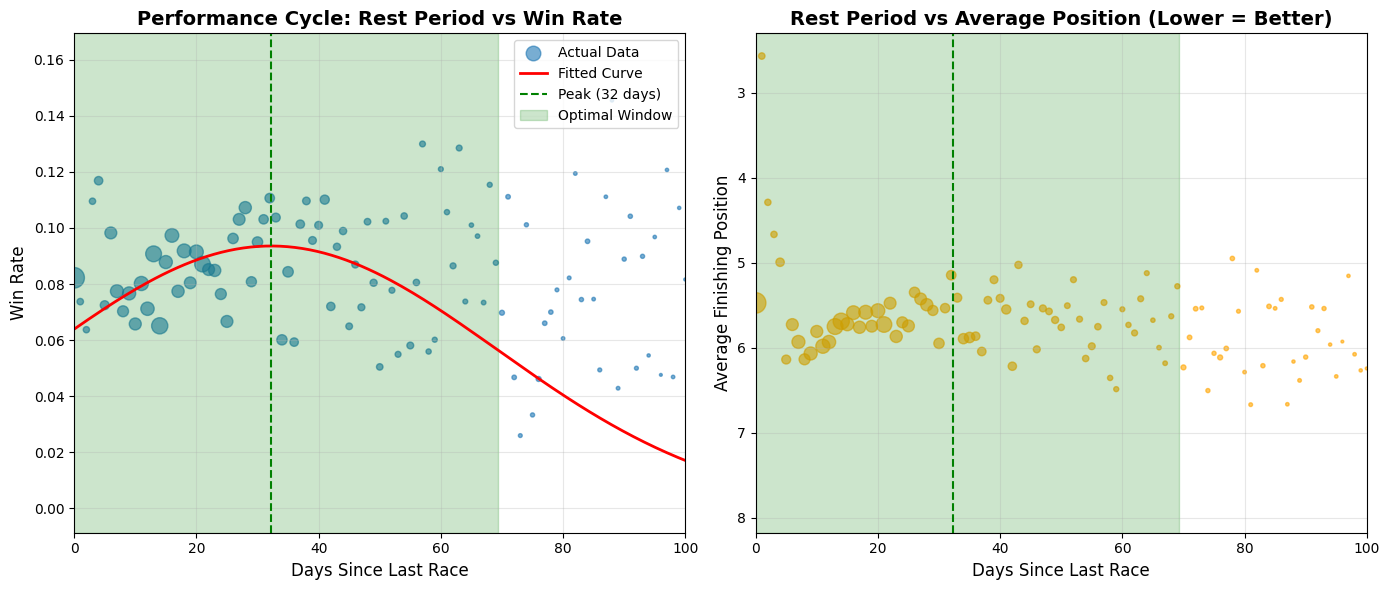


Using static bins: [-inf, 7, 14, 21, 35, 60, 120, inf]
Using static labels: ['too_soon (<=7d)', 'short (8-14d)', 'prime (15-21d)', 'optimal (22-35d)', 'medium (36-60d)', 'long (61-120d)', 'very_long (120+d)']
✓ Created 5 rest period features

FEATURE STRENGTH ANALYSIS

| Feature           |    Cramers_V |   P_Value |   Chi2_Stat | Notes                              |
|:------------------|-------------:|----------:|------------:|:-----------------------------------|
| in_optimal_window | 0.0108214947 |      0.02 |     5.15718 | Categories Kept: 3 (incl. 'Other') |
| rest_category     | 0.0255056232 |      0.00 |    28.649   | Categories Kept: 8 (incl. 'Other') |

REST PERIOD DISTRIBUTION
rest_category
too_soon (<=7d)      5213
short (8-14d)        6887
prime (15-21d)       6609
optimal (22-35d)     8449
medium (36-60d)      6223
long (61-120d)       4624
very_long (120+d)    6034
Name: count, dtype: int64

WIN RATE BY CATEGORY
rest_category
optimal (22-35d)     0.089123
prime (15-21d) 

/var/folders/j_/qzpvcxbn139f7y12swzzsdw40000gn/T/ipykernel_29374/360926303.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('rest_category')['winner'].mean().sort_values(ascending=False))


In [93]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# === STEP 0: Parse dates ===
# Extract date from track_name column (your existing logic)
def extract_race_date(track_name):
    """Extract date from track_name column"""
    if not isinstance(track_name, str):
        return None
    
    import re
    from datetime import datetime
    
    new = track_name.split('|', 1)[-1]
    cleaned_string = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', new)
    
    try:
        date_object = datetime.strptime(cleaned_string.strip(), "%d %B %Y %H:%M")
        return date_object
    except:
        return None

# Apply date extraction
print("Parsing race dates...")
df['race_date'] = df['track_name'].apply(extract_race_date)

# Convert to datetime (if not already)
df['race_date'] = pd.to_datetime(df['race_date'], errors='coerce')

# Remove rows with invalid dates
initial_len = len(df)
df = df[df['race_date'].notna()].copy()
print(f"Removed {initial_len - len(df)} rows with invalid dates")
print(f"Remaining rows: {len(df)}")

# === STEP 1: Calculate rest periods ===
print("\nCalculating rest periods...")
df = df.sort_values(['horse_name_clean', 'race_date']).reset_index(drop=True)
df['days_since_last_race'] = df.groupby('horse_name_clean')['race_date'].diff().dt.days

# Remove first race for each horse (NaN values)
df = df[df['days_since_last_race'].notna()].copy()
print(f"Rows with rest period data: {len(df)}")

# === STEP 2: Aggregate population pattern ===
print("\nAggregating population patterns...")
rest_perf = df.groupby('days_since_last_race').agg({
    'winner': ['mean', 'count'],
    'race_position_clean': 'mean'
}).reset_index()

rest_perf.columns = ['days_rest', 'win_rate', 'n_races', 'avg_position']

# Filter to stable estimates and reasonable rest periods (0-180 days)
rest_perf = rest_perf[
    (rest_perf['n_races'] >= 30) & 
    (rest_perf['days_rest'] >= 0) & 
    (rest_perf['days_rest'] <= 180)
]

print(f"Stable rest period bins: {len(rest_perf)}")
print("\nTop 10 rest periods by win rate:")
print(rest_perf.nlargest(10, 'win_rate')[['days_rest', 'win_rate', 'n_races']])
# === STEP 3: Fit the curve (Weighted) ===
print("\nFitting performance curve...")

def performance_curve(x, peak, height, width, base):
    """Gaussian curve: peaks at optimal rest, declines on either side"""
    return base + height * np.exp(-((x - peak) ** 2) / (2 * width ** 2))

try:
    # --- CHANGE 1: Calculate weights (sigma) ---
    # We'll use the standard deviation of the binomial proportion (win rate) as sigma.
    # sigma = sqrt(p * (1-p) / n)
    # A smaller sigma (less uncertainty) gives a point more weight.
    epsilon = 1e-6  # Add epsilon to avoid division by zero if win_rate is 0 or 1
    sigma = np.sqrt(
        (rest_perf['win_rate'] * (1 - rest_perf['win_rate']) + epsilon) / rest_perf['n_races']
    )
    # Give any remaining zero-sigma points a very high sigma (low weight)
    sigma[sigma <= 0] = 1.0

    # --- CHANGE 2: Pass sigma to curve_fit ---
    params, _ = curve_fit(
        performance_curve,
        rest_perf['days_rest'],
        rest_perf['win_rate'],
        p0=[21, 0.02, 15, 0.08],  # Adjusted initial guesses (peak, height, width, base)
        sigma=sigma,             # <-- Pass the weights
        absolute_sigma=True,     # <-- Treat sigma as the absolute standard deviation
        maxfev=10000
    )
    
    peak_day, peak_height, width, baseline = params
    
    print(f"\n🏆 RESULTS (Weighted):")
    print(f"   Optimal rest period: {peak_day:.1f} days")
    print(f"   Peak win rate: {(baseline + peak_height)*100:.1f}%")
    print(f"   Baseline win rate: {baseline*100:.1f}%")
    # Define optimal window as 1 standard deviation (width) from the peak
    window_start = max(0, peak_day - width)
    window_end = peak_day + width
    print(f"   Optimal window (1 std dev): {window_start:.1f} to {window_end:.1f} days")
    
except Exception as e:
    print(f"⚠️  Curve fitting failed: {e}")
    print("Using fallback linear features instead")
    peak_day, peak_height, width, baseline = 18, 0.03, 12, 0.08
    window_start, window_end = max(0, peak_day-width), peak_day+width
# === STEP 4: Visualize ===
plt.figure(figsize=(14, 6))

# Subplot 1: Win rate
plt.subplot(1, 2, 1)
plt.scatter(rest_perf['days_rest'], rest_perf['win_rate'], 
            s=rest_perf['n_races']/10, alpha=0.6, label='Actual Data')
x_range = np.linspace(0, 180, 300)
plt.plot(x_range, performance_curve(x_range, *params), 
         'r-', linewidth=2, label='Fitted Curve')
plt.axvline(peak_day, color='g', linestyle='--', linewidth=1.5, label=f'Peak ({peak_day:.0f} days)')
plt.axvspan(peak_day-width, peak_day+width, alpha=0.2, color='g', label='Optimal Window')
plt.xlabel('Days Since Last Race', fontsize=12)
plt.ylabel('Win Rate', fontsize=12)
plt.title('Performance Cycle: Rest Period vs Win Rate', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)

# Subplot 2: Average position
plt.subplot(1, 2, 2)
plt.scatter(rest_perf['days_rest'], rest_perf['avg_position'], 
            s=rest_perf['n_races']/10, alpha=0.6, color='orange')
plt.axvline(peak_day, color='g', linestyle='--', linewidth=1.5)
plt.axvspan(peak_day-width, peak_day+width, alpha=0.2, color='g')
plt.xlabel('Days Since Last Race', fontsize=12)
plt.ylabel('Average Finishing Position', fontsize=12)
plt.title('Rest Period vs Average Position (Lower = Better)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)
plt.gca().invert_yaxis()  # Lower position is better

plt.tight_layout()
plt.show()
# === STEP 5: Create features ===
# ... (Keep the first 4 feature creations: clipped, expected_perf, in_optimal_window, distance_from_peak) ...
# Note: 'in_optimal_window' and 'distance_from_peak' will now use the *new*, better-fitted peak_day and width.

# --- CHANGE 3: Use static, front-heavy bins ---
# This is more robust and addresses your request for "exponentially backing off" bins.
# We use -np.inf and np.inf to ensure all values are captured.
bins = [-np.inf, 7, 14, 21, 35, 60, 120, np.inf]
labels = [
    'too_soon (<=7d)',
    'short (8-14d)',
    'prime (15-21d)',
    'optimal (22-35d)',
    'medium (36-60d)',
    'long (61-120d)',
    'very_long (120+d)'
]

print(f"\nUsing static bins: {bins}")
print(f"Using static labels: {labels}")

df['rest_category'] = pd.cut(
    df['days_since_last_race'],
    bins=bins,
    labels=labels,
    right=True  # Bins include the right edge, e.g., (7, 14]
)

print(f"✓ Created 5 rest period features")
# === STEP 6: Test feature strength ===
print("\n" + "="*70)
print("FEATURE STRENGTH ANALYSIS")
print("="*70)

chi_squared_results = []

for col in ['in_optimal_window', 'rest_category']:
    feature, p_value, chi2_stat, cramers_v, notes = run_chi_squared_test(df, col, min_threshold=30)
    chi_squared_results.append({
        'Feature': feature,
        'Cramers_V': cramers_v,
        'P_Value': p_value,
        'Chi2_Stat': chi2_stat,
        'Notes': notes
    })

results_df = pd.DataFrame(chi_squared_results)
print("\n" + results_df.to_markdown(index=False, floatfmt=(".10f", ".10f", ".2f")))

# === STEP 7: Summary stats ===
print("\n" + "="*70)
print("REST PERIOD DISTRIBUTION")
print("="*70)
print(df['rest_category'].value_counts().sort_index())

print("\n" + "="*70)
print("WIN RATE BY CATEGORY")
print("="*70)
print(df.groupby('rest_category')['winner'].mean().sort_values(ascending=False))

print("\n✓ Pipeline complete!")

In [91]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from math import sqrt

# ======================================================================
# --- ASSUMPTIONS ---
# 1) Your DataFrame `df` is already loaded.
# 2) `df` contains:
#       - 'race_date' (date or datetime-like)
#       - 'trainer_clean', 'jockey_clean'
#       - 'winner' as 1/0
# 3) (Optional) 'days_since_last_win' (horse-level) already exists.
#    If it doesn't, this script will still run but will skip Feature 1.
# ======================================================================

# ======================================================================
# PART 1: FEATURE ENGINEERING  (NO LEAKAGE; uses shift(1))
# ======================================================================
print("="*70)
print("PART 1: ENGINEERING 'DAYS SINCE LAST WIN' FEATURES (NO LEAKAGE)")
print("="*70)

# --- Ensure 'race_date' is datetime
print("Converting 'race_date' to datetime objects...")
df['race_date'] = pd.to_datetime(df['race_date'], errors='coerce')

# --- Strict chronological sort (add more tie-breakers if available)
sort_cols = ['race_date']
# Add any columns you have that define within-day order (optional but recommended)
for c in ['race_time', 'race_datetime', 'meeting', 'race_number', 'race_id']:
    if c in df.columns:
        sort_cols.append(c)

df = df.sort_values(sort_cols).reset_index(drop=True)

# --- TRAINER feature (strictly prior wins only)
print("Engineering 'days_since_last_win_trainer' (leak-free)...")
df['trainer_win_date'] = df['race_date'].where(df['winner'].eq(1))
df['trainer_last_win_date'] = (
    df.groupby('trainer_clean', sort=False)['trainer_win_date']
      .ffill()
      .shift(1)   # <-- critical: removes current row from history
)
df['trainer_last_win_date'] = pd.to_datetime(df['trainer_last_win_date'], errors='coerce')

df['days_since_last_win_trainer'] = (
    df['race_date'] - df['trainer_last_win_date']
).dt.days
df['days_since_last_win_trainer'] = df['days_since_last_win_trainer'].fillna(999).astype(int)

# --- JOCKEY feature (strictly prior wins only)
print("Engineering 'days_since_last_win_jockey' (leak-free)...")
df['jockey_win_date'] = df['race_date'].where(df['winner'].eq(1))
df['jockey_last_win_date'] = (
    df.groupby('jockey_clean', sort=False)['jockey_win_date']
      .ffill()
      .shift(1)   # <-- critical
)
df['jockey_last_win_date'] = pd.to_datetime(df['jockey_last_win_date'], errors='coerce')

df['days_since_last_win_jockey'] = (
    df['race_date'] - df['jockey_last_win_date']
).dt.days
df['days_since_last_win_jockey'] = df['days_since_last_win_jockey'].fillna(999).astype(int)

# --- Clean up helper datetime columns
df = df.drop(columns=[
    'trainer_win_date', 'trainer_last_win_date',
    'jockey_win_date', 'jockey_last_win_date'
])

print("Feature engineering complete (no target leakage).\n")

# ======================================================================
# PART 2: UPDATED ANALYSIS SCRIPT
# ======================================================================
print("="*70)
print("UNDERSTANDING CRAMÉR'S V ADJUSTMENTS (UPDATED)")
print("="*70)

df_temp = df.copy()

# Helper to build binned categorical from a numeric "days since" feature
def build_binned(feature: str, min_threshold: int = 30, label: str = None):
    label = label or f"{feature}_binned"
    counts = df[feature].value_counts()
    keep = counts[counts >= min_threshold].index
    df_temp[label] = np.where(df[feature].isin(keep), df[feature], 'Other')
    # make sure it's categorical-like/object for crosstab
    df_temp[label] = df_temp[label].astype(object)
    return counts, keep, label

# ======================================================================
# FEATURE 1: days_since_last_win (Horse)  -> optional
# ======================================================================
if 'days_since_last_win' in df.columns:
    print("\n[1/3] days_since_last_win (Horse)")
    category_counts, keep_categories, binned_col_horse = build_binned('days_since_last_win', 30, 'days_since_last_win_binned')
    print(f"   Raw unique values: {df['days_since_last_win'].nunique()}")
    print(f"   Categories kept (n>=30): {len(keep_categories)}")
    print(f"   Categories lumped to 'Other': {df['days_since_last_win'].nunique() - len(keep_categories)}")

    print("\n   Top 10 bins by frequency:")
    print(df_temp[binned_col_horse].value_counts().head(10))

    win_rate_by_bin = (
        df_temp.groupby(binned_col_horse, dropna=False)['winner']
               .mean()
               .sort_values(ascending=False)
    )
    print("\n   Top 5 bins by win rate:")
    print(win_rate_by_bin.head())
else:
    print("\n[1/3] days_since_last_win (Horse) — SKIPPED (column not present).")
    binned_col_horse = None

# ======================================================================
# FEATURE 2: days_since_last_win_trainer
# ======================================================================
print("\n[2/3] days_since_last_win_trainer")
category_counts, keep_categories, binned_col_trainer = build_binned('days_since_last_win_trainer', 30, 'days_since_last_win_trainer_binned')
print(f"   Raw unique values: {df['days_since_last_win_trainer'].nunique()}")
print(f"   Categories kept (n>=30): {len(keep_categories)}")
print(f"   Categories lumped to 'Other': {df['days_since_last_win_trainer'].nunique() - len(keep_categories)}")

print("\n   Top 10 bins by frequency:")
print(df_temp[binned_col_trainer].value_counts().head(10))

win_rate_by_trainer_bin = (
    df_temp.groupby(binned_col_trainer, dropna=False)['winner']
           .mean()
           .sort_values(ascending=False)
)
print("\n   Top 5 trainer bins by win rate:")
print(win_rate_by_trainer_bin.head())

# ======================================================================
# FEATURE 3: days_since_last_win_jockey
# ======================================================================
print("\n[3/3] days_since_last_win_jockey")
category_counts, keep_categories, binned_col_jockey = build_binned('days_since_last_win_jockey', 30, 'days_since_last_win_jockey_binned')
print(f"   Raw unique values: {df['days_since_last_win_jockey'].nunique()}")
print(f"   Categories kept (n>=30): {len(keep_categories)}")
print(f"   Categories lumped to 'Other': {df['days_since_last_win_jockey'].nunique() - len(keep_categories)}")

print("\n   Top 10 jockey bins by frequency:")
print(df_temp[binned_col_jockey].value_counts().head(10))

win_rate_by_jockey_bin = (
    df_temp.groupby(binned_col_jockey, dropna=False)['winner']
           .mean()
           .sort_values(ascending=False)
)
print("\n   Top 5 jockey bins by win rate:")
print(win_rate_by_jockey_bin.head())

# ======================================================================
# CHI-SQUARED TEST COMPARISON
# ======================================================================
print("\n" + "="*70)
print("CHI-SQUARED TEST RESULTS (What Cramér's V Actually Measures)")
print("="*70)

chi_results = []

features_to_test = []
if binned_col_horse is not None:
    features_to_test.append(('days_since_last_win', binned_col_horse))
features_to_test.extend([
    ('days_since_last_win_trainer', binned_col_trainer),
    ('days_since_last_win_jockey', binned_col_jockey),
])

for col, lumped_col in features_to_test:
    contingency_table = pd.crosstab(df_temp[lumped_col], df_temp['winner'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    N = contingency_table.values.sum()
    r, k = contingency_table.shape
    phi2 = chi2 / N
    min_dim = min(r - 1, k - 1)
    cramers_v = sqrt(phi2 / min_dim) if min_dim > 0 else 0.0

    chi_results.append({
        'Feature': col,
        'Categories_Tested': r,
        'Cramers_V': cramers_v,
        'Chi2_Stat': chi2,
        'P_Value': p_value,
        'DOF': dof
    })

results_df = pd.DataFrame(chi_results)
print("\n" + results_df.to_markdown(index=False, floatfmt=(".10f", ".0f", ".10f")))

# ======================================================================
# VARIANCE COMPARISON
# ======================================================================
print("\n" + "="*70)
print("WIN RATE VARIANCE ACROSS CATEGORIES")
print("="*70)

if binned_col_horse is not None:
    print("\ndays_since_last_win (Horse):")
    print(f"   Min win rate: {win_rate_by_bin.min()*100:.2f}%")
    print(f"   Max win rate: {win_rate_by_bin.max()*100:.2f}%")
    print(f"   Range: {(win_rate_by_bin.max() - win_rate_by_bin.min())*100:.2f} pp")
    print(f"   Std Dev: {win_rate_by_bin.std()*100:.2f}%")

print("\ndays_since_last_win_trainer:")
print(f"   Min win rate: {win_rate_by_trainer_bin.min()*100:.2f}%")
print(f"   Max win rate: {win_rate_by_trainer_bin.max()*100:.2f}%")
print(f"   Range: {(win_rate_by_trainer_bin.max() - win_rate_by_trainer_bin.min())*100:.2f} pp")
print(f"   Std Dev: {win_rate_by_trainer_bin.std()*100:.2f}%")

print("\ndays_since_last_win_jockey:")
print(f"   Min win rate: {win_rate_by_jockey_bin.min()*100:.2f}%")
print(f"   Max win rate: {win_rate_by_jockey_bin.max()*100:.2f}%")
print(f"   Range: {(win_rate_by_jockey_bin.max() - win_rate_by_jockey_bin.min())*100:.2f} pp")
print(f"   Std Dev: {win_rate_by_jockey_bin.std()*100:.2f}%")

# ======================================================================
# INTERPRETATION
# ======================================================================
print("\n" + "="*70)
print("INTERPRETATION (post-leakage fix)")
print("="*70)
print("""
- Features are now computed with STRICTLY prior information using .shift(1),
  so today's win cannot influence today's 'days since' features.
- If you run the same table again, expect Cramér's V to drop from suspiciously
  high values (~0.7) to more realistic levels.
- For absolute robustness on same-day meetings, include exact race times or an
  intra-day ordering column in the initial sort (already supported in sort_cols).
""")


PART 1: ENGINEERING 'DAYS SINCE LAST WIN' FEATURES (NO LEAKAGE)
Converting 'race_date' to datetime objects...
Engineering 'days_since_last_win_trainer' (leak-free)...
Engineering 'days_since_last_win_jockey' (leak-free)...
Feature engineering complete (no target leakage).

UNDERSTANDING CRAMÉR'S V ADJUSTMENTS (UPDATED)

[1/3] days_since_last_win (Horse)
   Raw unique values: 2081
   Categories kept (n>=30): 673
   Categories lumped to 'Other': 1408

   Top 10 bins by frequency:
days_since_last_win_binned
Other    18718
0.0        228
21.0       206
28.0       168
20.0       163
35.0       161
13.0       154
14.0       148
27.0       134
23.0       134
Name: count, dtype: int64

   Top 5 bins by win rate:
days_since_last_win_binned
0.0       0.771930
-64.0     0.235294
333.0     0.234043
-197.0    0.212121
-353.0    0.212121
Name: winner, dtype: float64

[2/3] days_since_last_win_trainer
   Raw unique values: 549
   Categories kept (n>=30): 162
   Categories lumped to 'Other': 387

   T

In [92]:
# 1️⃣  Sort chronologically within jockey–horse pair
df = df.sort_values(['jockey', 'horse_name', 'race_date'])

# 2️⃣  Runs so far (before this race)
df['j_h_runs'] = df.groupby(['jockey', 'horse_name']).cumcount()

# 3️⃣  Wins so far (before this race)
df['j_h_wins'] = (
    df.groupby(['jockey', 'horse_name'])['winner']
      .cumsum()                # cumulative wins *including* current race
      .shift(1)                # exclude the current race result  → strictly prior
      .fillna(0)
      .astype(int)
)

print(df['j_h_runs'].describe())
print(df['j_h_wins'].describe())

# 4️⃣  Inspect pairs with above-average prior wins
# print(df.loc[df['j_h_wins'] > 4 , ['jockey','horse_name','j_h_runs','j_h_wins']])


chi_squared_results = []

for col in ['j_h_runs', 'j_h_wins', 'days_since_last_race']:
    feature, p_value, chi2_stat, cramers_v, notes = run_chi_squared_test(df, col, min_threshold=30)
    chi_squared_results.append({
        'Feature': feature,
        'Cramers_V': cramers_v,
        'P_Value': p_value,
        'Chi2_Stat': chi2_stat,
        'Notes': notes
    })

results_df = pd.DataFrame(chi_squared_results)
print("\n" + results_df.to_markdown(index=False, floatfmt=(".10f", ".10f", ".2f")))
print(df.head(0))


count    53459.000000
mean         0.927496
std          1.692973
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         28.000000
Name: j_h_runs, dtype: float64
count    53478.000000
mean         0.198867
std          0.499753
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: j_h_wins, dtype: float64

| Feature              |    Cramers_V |   P_Value |   Chi2_Stat | Notes                                |
|:---------------------|-------------:|----------:|------------:|:-------------------------------------|
| j_h_runs             | 0.0286324540 |      0.00 |     43.8422 | Categories Kept: 14 (incl. 'Other')  |
| j_h_wins             | 0.0670802847 |      0.00 |    240.638  | Categories Kept: 6 (incl. 'Other')   |
| days_since_last_race | 0.0683115502 |      0.25 |    249.553  | Categories Kept: 236 (incl. 'Other') |
Empty DataFrame
Columns: [track_name, race_date, race_time, 